In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
import numpy as np

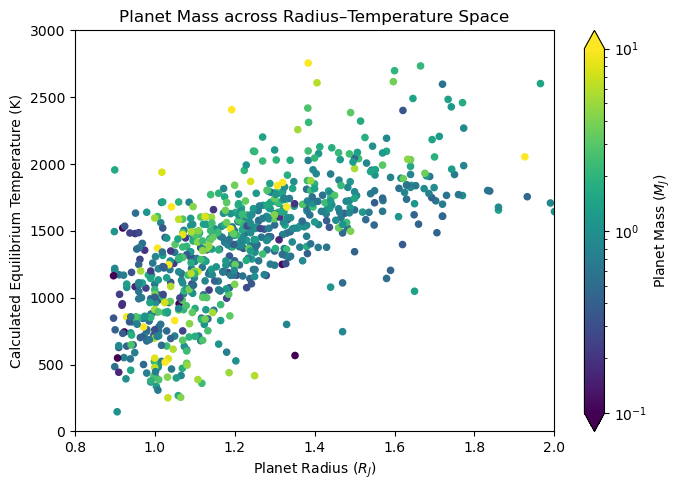

In [2]:
# Load CSV
df = pd.read_csv(
    "RankedTEPSet_TNT ULTRASPEC_r-band_for_Half_Well_Y-SkyNoise_N-Defocus.csv"
)

# -------------------------------
# Plot 1: Rp vs Teq_Calc, colored by Mp (log color scale)
# -------------------------------
df_plot = df[(df["Rp"] > 0.892147) & (df["Mp"] > 0)].copy()

plt.figure(figsize=(7, 5))

sc = plt.scatter(
    df_plot["Rp"],
    df_plot["Teq_Calc"],
    c=df_plot["Mp"],
    norm=LogNorm(vmin=1e-1, vmax=1e1),  # cap colorbar range
    s=20,
)

plt.xlabel("Planet Radius ($R_J$)")
plt.ylabel("Calculated Equilibrium Temperature (K)")
plt.title("Planet Mass across Radius–Temperature Space")

cbar = plt.colorbar(sc, extend="both")
cbar.set_label("Planet Mass ($M_J$)")

plt.xlim(0.8,2.0)
plt.ylim(0,3000)

plt.tight_layout()
plt.show()

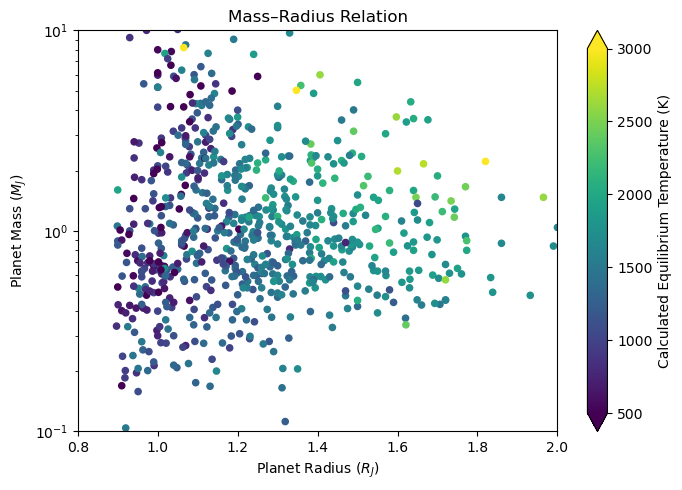

In [3]:
plt.figure(figsize=(7, 5))

sc = plt.scatter(
    df_plot["Rp"],
    df_plot["Mp"],
    c=df_plot["Teq_Calc"],
    vmin=500,
    vmax=3000,
    s=20,
)

plt.xlabel("Planet Radius ($R_J$)")
plt.ylabel("Planet Mass ($M_J$)")
plt.title("Mass–Radius Relation")

# plt.xscale("log")
plt.yscale("log")

cbar = plt.colorbar(sc, extend="both")
cbar.set_label("Calculated Equilibrium Temperature (K)")

plt.xlim(0.8,2.0)
plt.ylim(1e-1,1e+1)

plt.tight_layout()
plt.show()

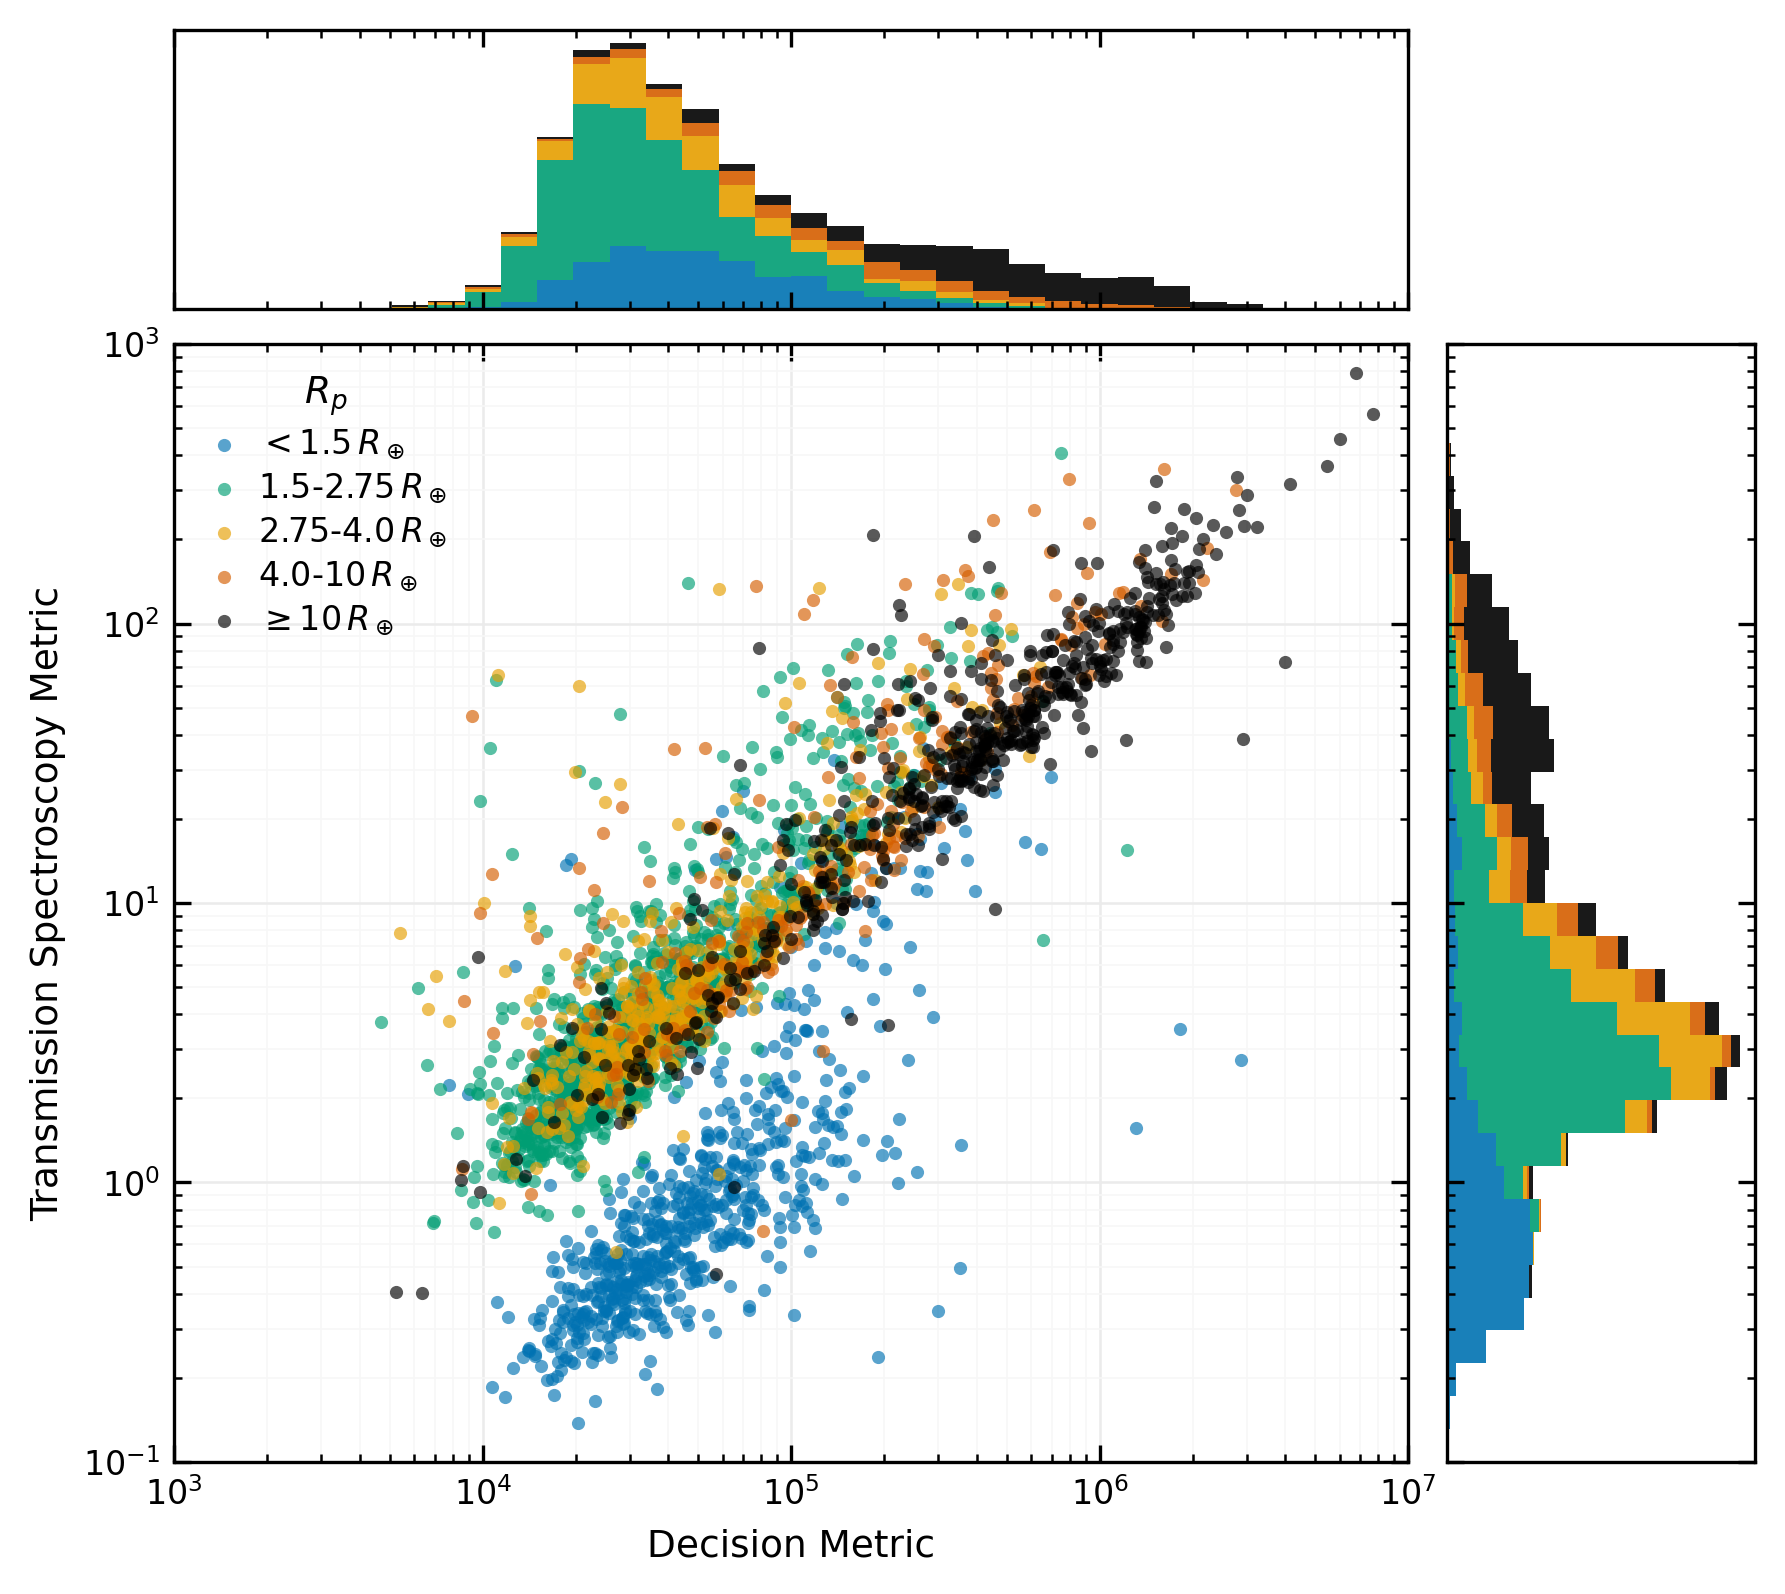

In [8]:
import matplotlib.pyplot as plt
from matplotlib import gridspec
import numpy as np

# -----------------------------------------------------------------------------
# MNRAS style
# -----------------------------------------------------------------------------
plt.rcParams.update({
    "font.size": 9,
    "axes.labelsize": 9,
    "axes.linewidth": 0.8,
    "xtick.labelsize": 8,
    "ytick.labelsize": 8,
    "legend.fontsize": 8,
    "figure.dpi": 300,
})

# -----------------------------------------------------------------------------
# Radius regimes (Rp in Jupiter radii)
# -----------------------------------------------------------------------------
RE_PER_RJ = 11.21

R_SMALL      = 1.5 / RE_PER_RJ
R_SUBNEPTUNE = 2.75 / RE_PER_RJ
R_SUBSATURN  = 4.0 / RE_PER_RJ
R_GIANT      = 10.0 / RE_PER_RJ

# Okabe-Ito colours
regimes = [
    (df["Rp"] < R_SMALL,
     r"$<1.5\,R_\oplus$",
     "#0072B2"),

    ((df["Rp"] >= R_SMALL) & (df["Rp"] < R_SUBNEPTUNE),
     r"$1.5$-$2.75\,R_\oplus$",
     "#009E73"),

    ((df["Rp"] >= R_SUBNEPTUNE) & (df["Rp"] < R_SUBSATURN),
     r"$2.75$-$4.0\,R_\oplus$",
     "#E69F00"),

    ((df["Rp"] >= R_SUBSATURN) & (df["Rp"] < R_GIANT),
     r"$4.0$-$10\,R_\oplus$",
     "#D55E00"),

    (df["Rp"] >= R_GIANT,
     r"$\geq10\,R_\oplus$",
     "black"),
]

# -----------------------------------------------------------------------------
# Figure layout
# -----------------------------------------------------------------------------
fig = plt.figure(figsize=(6.8, 6.2))

gs = gridspec.GridSpec(
    2,
    2,
    width_ratios=[4, 1],
    height_ratios=[1, 4],
    hspace=0.05,
    wspace=0.05,
)

ax_histx = fig.add_subplot(gs[0, 0])
ax = fig.add_subplot(gs[1, 0], sharex=ax_histx)
ax_histy = fig.add_subplot(gs[1, 1], sharey=ax)

# -----------------------------------------------------------------------------
# Limits
# -----------------------------------------------------------------------------
xmin, xmax = 1e3, 1e7
ymin, ymax = 1e-1, 1e3

xbins = np.logspace(np.log10(xmin), np.log10(xmax), 35)
ybins = np.logspace(np.log10(ymin), np.log10(ymax), 35)

rank_data = []
tsm_data = []
colors = []

# -----------------------------------------------------------------------------
# Scatter
# -----------------------------------------------------------------------------
for mask, label, color in regimes:

    d = df.loc[
        mask &
        (df["Rank"] > 0) &
        (df["TSM"] > 0)
    ]

    ax.scatter(
        d["Rank"],
        d["TSM"],
        s=10,
        color=color,
        alpha=0.65,
        linewidths=0,
        rasterized=True,
        label=label,
    )

    rank_data.append(d["Rank"])
    tsm_data.append(d["TSM"])
    colors.append(color)

# -----------------------------------------------------------------------------
# Marginal histograms
# -----------------------------------------------------------------------------
ax_histx.hist(
    rank_data,
    bins=xbins,
    stacked=True,
    color=colors,
    edgecolor="none",
    alpha=0.9,
)

ax_histy.hist(
    tsm_data,
    bins=ybins,
    stacked=True,
    orientation="horizontal",
    color=colors,
    edgecolor="none",
    alpha=0.9,
)

# -----------------------------------------------------------------------------
# Axes
# -----------------------------------------------------------------------------
for a in (ax, ax_histx):
    a.set_xscale("log")

for a in (ax, ax_histy):
    a.set_yscale("log")

ax.set_xlim(xmin, xmax)
ax.set_ylim(ymin, ymax)

# -----------------------------------------------------------------------------
# Grid & ticks
# -----------------------------------------------------------------------------
for a in (ax, ax_histx, ax_histy):

    a.minorticks_on()

    a.tick_params(
        direction="in",
        which="both",
        top=True,
        right=True,
        length=4,
    )

    a.tick_params(
        which="minor",
        length=2,
    )

ax.grid(
    True,
    which="major",
    color="0.92",
    linewidth=0.6,
)

ax.grid(
    True,
    which="minor",
    color="0.97",
    linewidth=0.4,
)

ax.set_axisbelow(True)

# -----------------------------------------------------------------------------
# Hide histogram tick labels
# -----------------------------------------------------------------------------
ax_histx.tick_params(
    labelbottom=False,
    labelleft=False,
)

ax_histy.tick_params(
    labelleft=False,
    labelbottom=False,
)

# Remove histogram ticks
ax_histx.set_yticks([])
ax_histy.set_xticks([])

# -----------------------------------------------------------------------------
# Labels
# -----------------------------------------------------------------------------
ax.set_xlabel("Decision Metric")
ax.set_ylabel("Transmission Spectroscopy Metric")

# -----------------------------------------------------------------------------
# Legend
# -----------------------------------------------------------------------------
ax.legend(
    title=r"$R_p$",
    frameon=False,
    loc="upper left",
    handlelength=1.2,
    handletextpad=0.4,
    labelspacing=0.3,
)

plt.show()

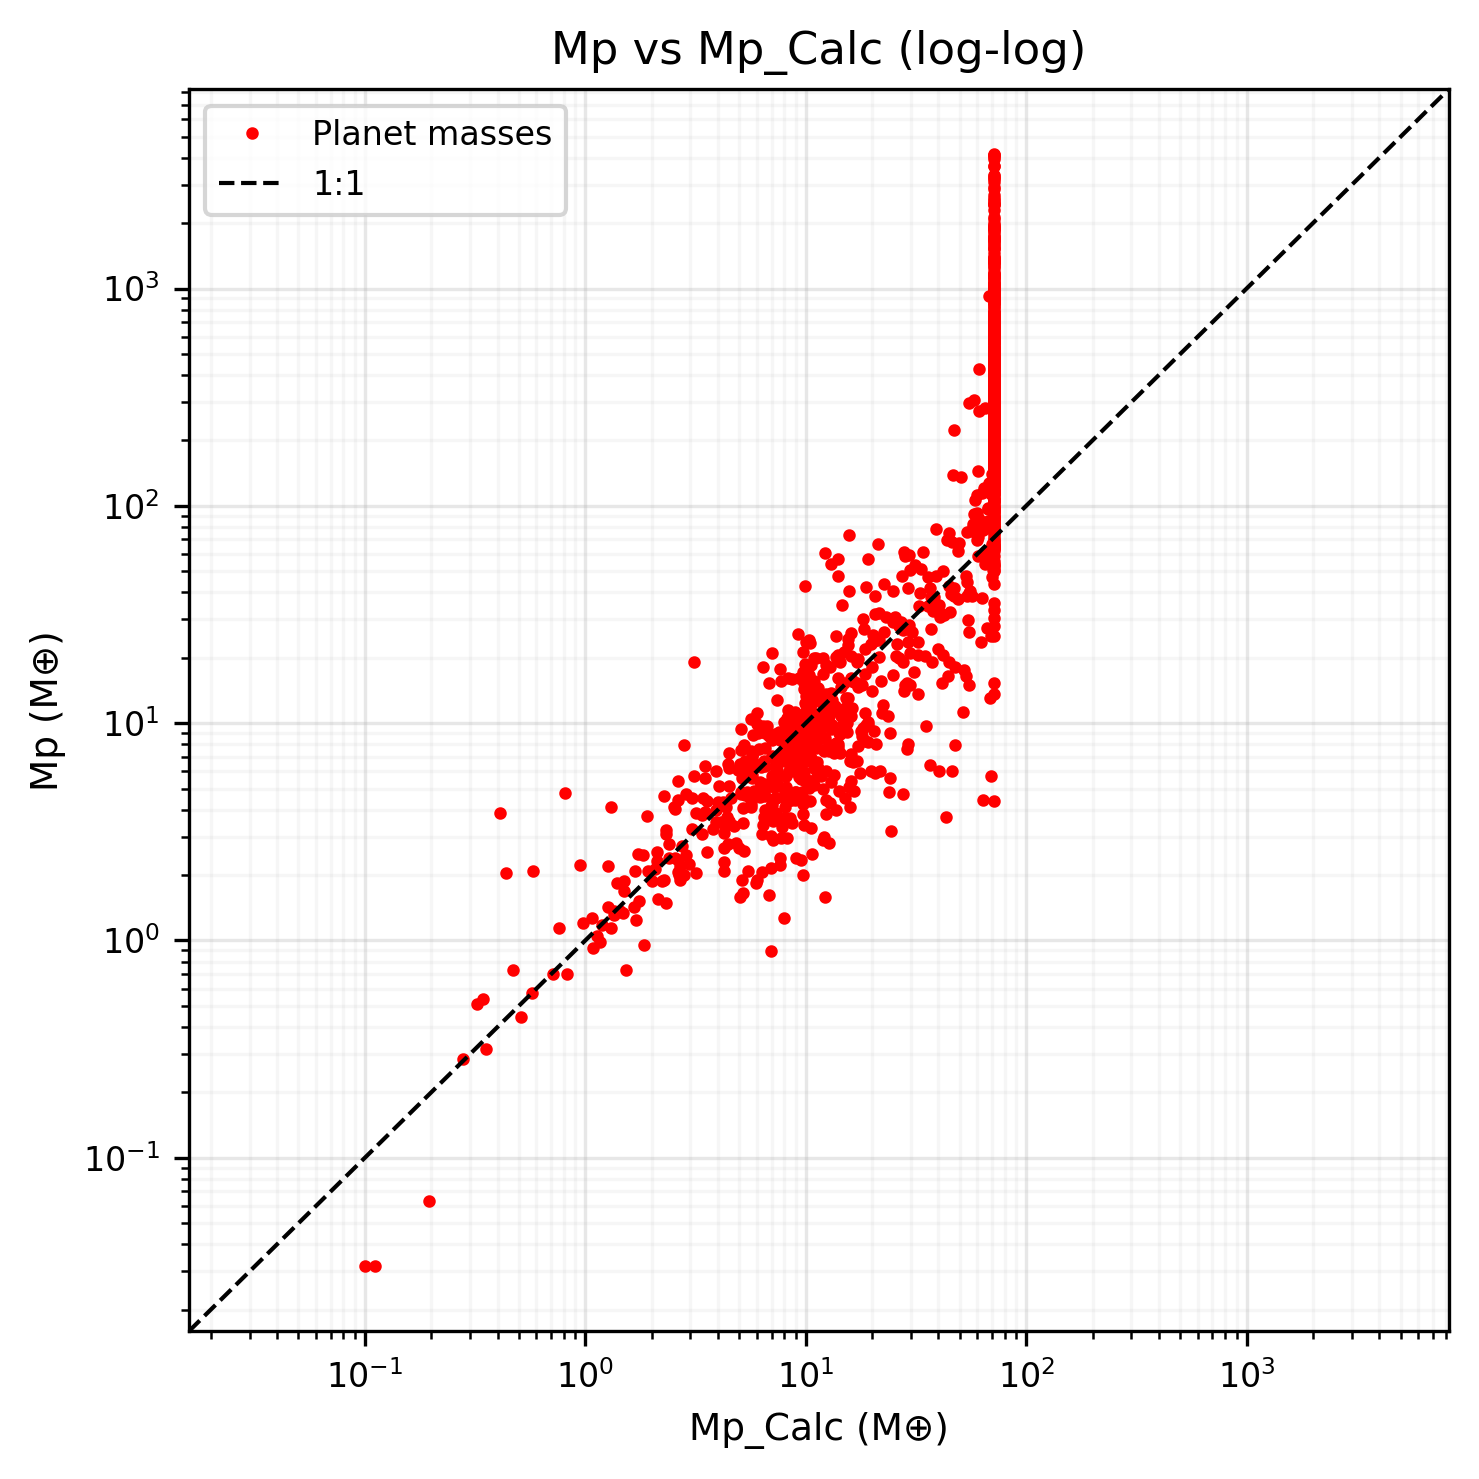

In [5]:
# -------------------------------
# Plot 2: Mp vs Mp_Calc (log-log)
# -------------------------------
x = df["Mp_Calc"] * 317.82 
y = df["Mp"] * 317.82 

mask = (x > 0) & (y > 0)

x = x[mask]
y = y[mask]

plt.figure(figsize=(5, 5))

plt.loglog(x, y, ".", markersize=4, c="red", label="Planet masses")

# 1:1 reference line
lims = [
    np.nanmin([x.min(), y.min()])/2,
    np.nanmax([x.max(), y.max()])*2
]
plt.loglog(lims, lims, "k--", linewidth=1, label="1:1")

plt.xlabel("Mp_Calc (M⊕)")
plt.ylabel("Mp (M⊕)")
plt.title("Mp vs Mp_Calc (log-log)")

plt.grid(True, which="major", alpha=0.3)
plt.grid(True, which="minor", alpha=0.1)
plt.legend()

plt.xlim(lims)
plt.ylim(lims)

plt.tight_layout()
plt.show()